# Project 1: Implementing Decision Trees

Predicting which customers are likely to leave (churn) and which will stay (no-churn) is important for telecommunications companies, because it lets them target their effort into what matters most. In this project we implemented a decision tree from scratch (*decision_tree.py*), use it to predict churn, and compare it to exsisting implemetations. 

In this notebook we will:
| Section | Description |
|---|---|
| 1 | Test the decision tree implementation on small examples |
| 2 | Choose the best settings for the decision tree algorithm by performing model selection. |
| 3 | Estimate the importance of each feature in our decision tree implementation with a permutation importance algorithm |

## Section 0 - Setup
### Importing libraries and the decision tree

The cell below loads the libraries and the functions implemented in **`decision_tree.py`**.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, recall_score, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier

from decision_tree import DecisionTree, entropy, gini, permutation_importance


## Section 1 - Testing the decision tree implementation


### Test entropy and Gini on known label distributions


In [14]:
# All examples belong to one class: no impurity.
pure_labels = np.array([0, 0, 0, 0])

assert np.isclose(entropy(pure_labels), 0.0)
assert np.isclose(gini(pure_labels), 0.0)

# Two equally common classes.
balanced_labels = np.array([0, 0, 1, 1])

assert np.isclose(entropy(balanced_labels), 1.0)
assert np.isclose(gini(balanced_labels), 0.5)

# Three equally common classes.
three_classes = np.array([0, 1, 2])

assert np.isclose(entropy(three_classes), np.log2(3))
assert np.isclose(gini(three_classes), 2 / 3)

print("Impurity tests passed.")

Impurity tests passed.


### Test training and prediction on a small dataset


In [15]:
# Four examples, each with one feature.
toy_X = np.array([[1], [2], [8], [9]])
toy_y = np.array([0, 0, 1, 1])

# New examples whose expected predictions we can work out.
new_X = np.array([[3], [5], [7]])
expected = np.array([0, 0, 1])

for criterion in ["entropy", "gini"]:
    tree = DecisionTree(criterion=criterion)
    tree.fit(toy_X, toy_y)

    actual = tree.predict(new_X)

    np.testing.assert_array_equal(actual, expected)
    print(f"Training and prediction test passed: {criterion}")

Training and prediction test passed: entropy
Training and prediction test passed: gini


## Section 2 - Model selection and evaluation
> Approximately 73% of customers stay, so predicting “stays” for everyone would achieve 73% accuracy while missing every customer who churns.

### Loading customer data and separating features from churn labels


In [16]:
# Code given in instructions
df = np.genfromtxt("data/churn-data.csv", delimiter=",", dtype=float, names=True)

feature_names = list(df.dtype.names[:-1])
target_name = df.dtype.names[-1]

X = np.array([df[feature] for feature in feature_names]).T
y = df[target_name].astype(int)

print(f"Feature columns names: {feature_names}")
print(f"Target column name: {target_name}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

Feature columns names: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']
Target column name: Churn
X shape: (7032, 19)
y shape: (7032,)


In [17]:
stays = np.sum(y == 0)
churns = np.sum(y == 1)

print(f"Stays (0): {stays} customers ({round(stays / len(y), 1)})")
print(f"Churns (1): {churns} customers ({round(churns / len(y), 1)})")

Stays (0): 5163 customers (0.7)
Churns (1): 1869 customers (0.3)


### Splitting data into training, validation, and test sets (60/20/20)


In [18]:
seed = 67

X_val_test, X_test, y_val_test, y_test = train_test_split(
    X, y, test_size=0.20, random_state=seed, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_val_test, y_val_test,
    test_size=0.25, random_state=seed, stratify=y_val_test
)

# We chose 60/20/20 instead of 70/15/15 because larger validation and test sets
# make performance estimates less sensitive to which customers end up in each set.

### Training an initial tree and measure validation performance


In [19]:
# Create a tree and train it.
model = DecisionTree() #max = none, entropy
model.fit(X_train, y_train)

# Predict labels for the validation customers.
val_predictions = model.predict(X_val)

# Compare predictions with the actual labels.
val_accuracy = accuracy_score(y_val, val_predictions)
val_f1 = f1_score(
    y_val, val_predictions, pos_label=1, zero_division=0
)

print(f"Validation accuracy test: {round(val_accuracy, 3)}")
print(f"Validation F1 test:       {round(val_f1, 3)}")

Validation accuracy test: 0.732
Validation F1 test:       0.501


### 2.1 - Choosing settings for our decision tree


In [20]:
results = []
best_f1 = -1
best_settings = None

# Testing both criterions and a set of different max depths
for criterion in ["entropy", "gini"]:
    for depth in [1, 2, 3, 5, 10, None]:

        candidate = DecisionTree(
            criterion=criterion,
            max_depth=depth
        )
        candidate.fit(X_train, y_train)

        predictions = candidate.predict(X_val)

        accuracy = accuracy_score(y_val, predictions)
        f1 = f1_score(
            y_val, predictions, pos_label=1, zero_division=0
        )

        # Saving test results for every tree
        results.append({
            "criterion": criterion,
            "depth": "unlimited" if depth is None else depth,
            "accuracy": accuracy,
            "F1": f1
        })

        # Comparing last best tree-settings to current tree settings.
        # Setting best to current if current is better than best.
        if f1 > best_f1:
            best_f1 = f1
            best_settings = {
                "criterion": criterion,
                "max_depth": depth
            }

results_table = pd.DataFrame(results)
display(results_table.sort_values("F1", ascending=False))

print("Best settings:", best_settings)
print(f"Best validation F1: {round(best_f1, 3)}")

,criterion,depth,accuracy,F1
9,gini,5,0.781805,0.601816
3,entropy,5,0.780384,0.593955
7,gini,2,0.732054,0.592432
1,entropy,2,0.732054,0.592432
8,gini,3,0.774698,0.549075
2,entropy,3,0.774698,0.549075
4,entropy,10,0.754087,0.539894
10,gini,10,0.746269,0.529644
11,gini,unlimited,0.725657,0.502577
5,entropy,unlimited,0.732054,0.500662


Best settings: {'criterion': 'gini', 'max_depth': 5}
Best validation F1: 0.602


F1 is 0 when max depth is 1, because the tree predicts "no-churn" for all the customers. Making it the worst setting. Accuracy still evaluates to 0.734, since it's the proportion of "no-churn" in the data. This shows how accuracy alone can fool us, and why we also choose to include F1 in our tests. 


### 2.2 - Choosing settings for the sklearn decision tree


In [21]:
sklearn_results = []
sklearn_best_f1 = -1
sklearn_best_settings = None

# Using the same function to test for best settings for sklearn decision tree as ours.
for criterion in ["entropy", "gini"]:
    for depth in [1, 2, 3, 5, 10, None]:
        candidate = DecisionTreeClassifier(
            criterion=criterion,
            max_depth=depth,
            random_state=seed
        )
        candidate.fit(X_train, y_train)

        predictions = candidate.predict(X_val)

        accuracy = accuracy_score(y_val, predictions)
        score = f1_score(
            y_val, predictions, pos_label=1, zero_division=0
        )

        sklearn_results.append({
            "criterion": criterion,
            "depth": "unlimited" if depth is None else depth,
            "accuracy": accuracy,
            "F1": score
        })

        if score > sklearn_best_f1:
            sklearn_best_f1 = score
            sklearn_best_settings = {
                "criterion": criterion,
                "max_depth": depth
            }
sklearn_table = pd.DataFrame(sklearn_results)
display(
    sklearn_table.sort_values("F1", ascending=False)
)

print("Best sklearn settings:", sklearn_best_settings)
print(f"Best sklearn validation F1: {round(sklearn_best_f1,3)}")

,criterion,depth,accuracy,F1
1,entropy,2,0.732054,0.592432
7,gini,2,0.732054,0.592432
9,gini,5,0.796020,0.552262
3,entropy,5,0.791045,0.519608
10,gini,10,0.759773,0.508721
4,entropy,10,0.751244,0.501425
5,entropy,unlimited,0.726368,0.498044
11,gini,unlimited,0.718550,0.484375
8,gini,3,0.778252,0.417910
2,entropy,3,0.778252,0.417910


Best sklearn settings: {'criterion': 'entropy', 'max_depth': 2}
Best sklearn validation F1: 0.592


### Refitting both selected models and compare test performance


In [22]:
final_custom = DecisionTree(
    criterion=best_settings["criterion"],
    max_depth=best_settings["max_depth"]
)

final_sklearn = DecisionTreeClassifier(
    criterion=sklearn_best_settings["criterion"],
    max_depth=sklearn_best_settings["max_depth"],
    random_state=seed
)

# Refit using the combined training and validation data.
final_custom.fit(X_val_test, y_val_test)
final_sklearn.fit(X_val_test, y_val_test)

# Evaluate the selected models on the held-out test set.
test_results = []

for name, fitted_model in [
    ("Our tree", final_custom),
    ("Sklearn tree", final_sklearn)
]:
    predictions = fitted_model.predict(X_test)

    test_results.append({
        "model": name,
        "test_accuracy": accuracy_score(y_test, predictions),
        "test_F1": f1_score(
            y_test, predictions, pos_label=1, zero_division=0
        )
    })

display(pd.DataFrame(test_results))

,model,test_accuracy,test_F1
0,Our tree,0.798152,0.573574
1,Sklearn tree,0.737029,0.579545


## 2.3 Comparing validation results
### Validation vs. Max depth

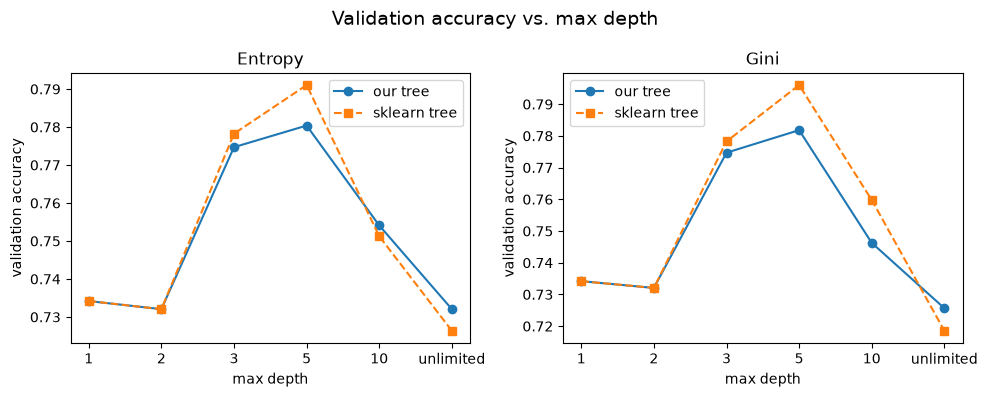

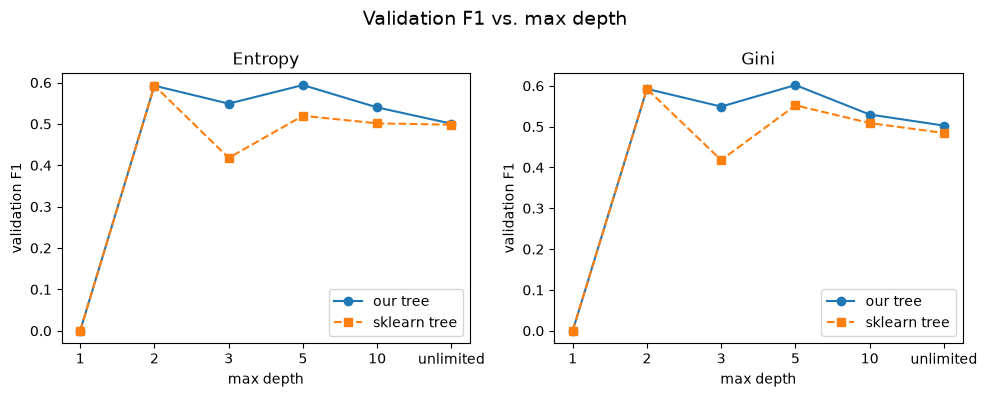

In [23]:
positions = [0,1,2,3,4,5]
labels = [1, 2, 3, 5, 10, "unlimited"] #can't use None, since its not a number

for metric in ["accuracy","F1"]:
    our_entropy = results_table[results_table["criterion"] == "entropy"][metric]
    our_gini = results_table[results_table["criterion"] == "gini"][metric]

    sk_entropy = sklearn_table[sklearn_table["criterion"] == "entropy"][metric]
    sk_gini = sklearn_table[sklearn_table["criterion"] == "gini"][metric]

    plt.figure(figsize=(10,4))
    plt.suptitle(f"Validation {metric} vs. max depth", fontsize=14)

    #entropy plot
    plt.subplot(1,2,1)
    plt.plot(positions, our_entropy, marker ="o", label= "our tree" )
    plt.plot(positions, sk_entropy, marker ="s", linestyle= "--",label= "sklearn tree" )
    plt.title("Entropy")
    plt.ylabel(f"validation {metric}")
    plt.xlabel("max depth")
    plt.xticks(positions, labels)
    # plt.ylim(0,0.7)
    plt.legend()

    #gini plot
    plt.subplot(1,2,2)
    plt.plot(positions, our_gini, marker ="o", label= "our tree" )
    plt.plot(positions, sk_gini, marker ="s", linestyle= "--",label= "sklearn tree" )
    plt.title("Gini")
    plt.ylabel(f"validation {metric}")
    plt.xlabel("max depth")
    plt.xticks(positions, labels)
    # plt.ylim(0,0.7)
    plt.legend()

    plt.tight_layout()
    plt.show()

### Confusion matrix

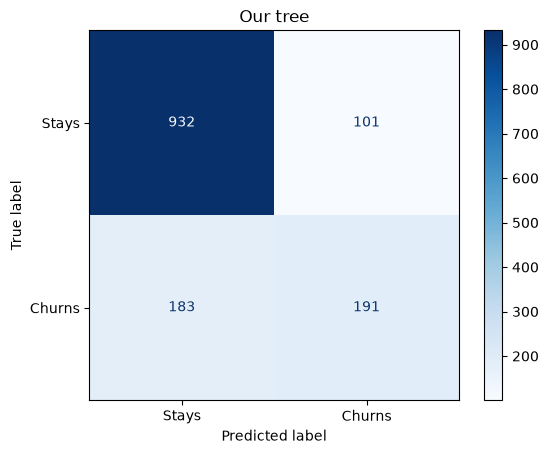

Our tree: recall for churn = 0.5


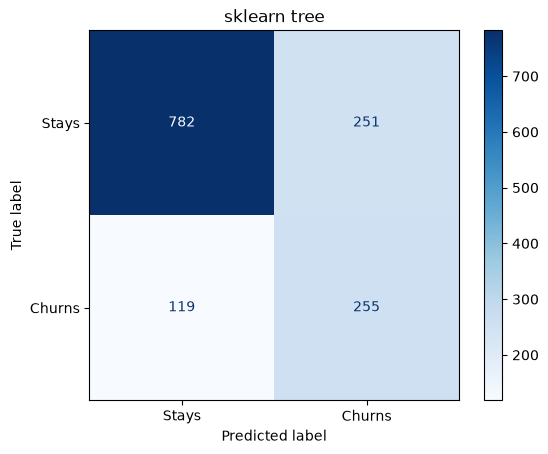

sklearn tree: recall for churn = 0.7


In [24]:
for name, fitted_model in [
    ("Our tree", final_custom),
    ("sklearn tree", final_sklearn)
]:
    test_predictions = fitted_model.predict(X_test)
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        test_predictions,
        labels=[0,1],
        display_labels=["Stays", "Churns"],
        cmap="Blues"
    )

    plt.title(name)
    plt.show()
    
    recall_churn = recall_score(y_test, test_predictions, pos_label=1)
    print(f"{name}: recall for churn = {round(recall_churn, 1)}")

#### Confusion matrix conclusion
> Our tree used gini with max depth 5 (validation F1 ≈ 0.602), while the sklearn tree used entropy with max depth 2 (validation F1 ≈ 0.592).

Both models are better at correctly predicting whether a customer stays, while both have a more difficult time correctly predicting when a customer churns. Our tree is more accurate when predicting when predicting if a customer stays with an accuracy of about 90% while the sklearn tree has an accuracy of about 76%. The sklearn tree is however more accurate when predicting if a customer cherns, having an accuracy of abour 68%, while ours only has about 51%%.

- **Recall** (for churn) is the share of the customers who actually churned that the model found.

## Section 3 - Feature Importance

### 3.1 Permutation importance on the test set



,feature,importance_mean,importance_std
4,tenure,0.0569,0.0074
8,OnlineSecurity,0.0359,0.0076
14,Contract,0.0338,0.0052
7,InternetService,0.0208,0.0052
9,OnlineBackup,0.0149,0.0039
12,StreamingTV,0.0020,0.0019
0,gender,0.0000,0.0000
2,Partner,0.0000,0.0000
1,SeniorCitizen,0.0000,0.0000
6,MultipleLines,0.0000,0.0000


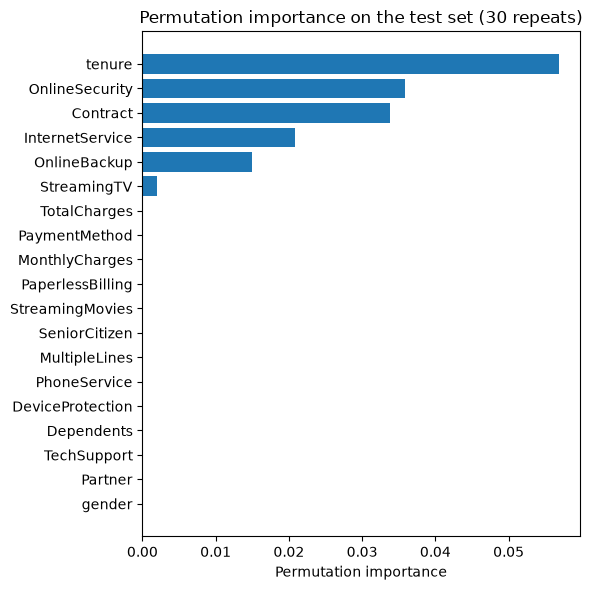

In [25]:
importanceScores = permutation_importance(final_custom, X_test, y_test, accuracy_score, 30, seed)

importanceTable = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': importanceScores.mean(axis = 1),
    'importance_std':importanceScores.std(axis = 1),
})

#table with features and their importance
importanceTable = importanceTable.sort_values("importance_mean", ascending=False).round(4)
display(importanceTable)

#the data presented in a bar plot
plot_data = importanceTable.sort_values('importance_mean') #ascending, so the smalles comes first

plt.figure(figsize =(6, 6))
plt.barh(plot_data['feature'], plot_data['importance_mean'])  #horizontal bar plot + 
plt.xlabel("Permutation importance")
plt.title("Permutation importance on the test set (30 repeats)")

plt.tight_layout()
plt.show()

#### Feature Importance Conclusion
Feature with importance 0 (and std 0) didn't change the model's predictions when it was randomly permuted. This means the model isn't dependent on them, and likely doesn't use them at all.